# Workshop 5: Coding Agents for Data Exploration

In **Workshop 4**, we built a small set of **composable analytics tools** and saw how tool design affects correctness and reliability.

In **Workshop 5**, we add a new capability:

> Let the assistant write **Python code** (with guardrails) to handle analyses that don’t fit our tool DSL.

We’ll keep the same dataset (**Pokémon**) for continuity.

## Today’s agenda

1) Recap: our composable analytics toolset (Workshop 4)  
2) Current limitations: where tools start to feel limiting  
3) LLM Code Generation experiment  
4) Build a **safe-ish code executor** and test it  
5) Build a **Coding Agent** loop (plan → code → run → retry) with a trace  
6) Demos: analyses that are much easier with a coding agent  
7) Security: what’s risky, and stronger/better sandboxing options  
8) Exercises


## Part 0: Setup

In [1]:
# Core imports
import os
import json
import uuid
import ast
import io
import contextlib
from dataclasses import dataclass, field
from typing import Any, Dict, List, Literal, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


from utils.display import heading, output_box, compare_table, llm_response, separator


from openai import OpenAI

client = OpenAI() if OpenAI is not None else None
MODEL = "gpt-4o-mini"

## Part 0.1: Load the Pokémon dataset (continuity from Workshop 4)

We’ll normalize column names into `snake_case` so they’re easy to use in code and tools.


In [2]:
DATA_PATH = "./data/Pokemon.csv"

df_raw = pd.read_csv(DATA_PATH)

df = df_raw.copy()
df.columns = (
    df.columns
      .str.replace(" ", "_", regex=False)
      .str.replace(".", "", regex=False)
      .str.lower()
)

heading("Dataset loaded", level=3)
output_box(
    f"Path: {DATA_PATH}\nRows: {df.shape[0]}\nColumns: {df.shape[1]}",
    label="✅ Ready",
    style="success",
)

heading("Columns", level=3)
output_box(", ".join(df.columns.tolist()), label="Schema", style="info")

df.head(10)


### Dataset loaded

### Columns

,#,name,type_1,type_2,total,hp,attack,defense,sp_atk,sp_def,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


## Part 0.2: State (tables + `table_id`) and JSON-safe helpers

In [3]:
# -----------------------------
# State: tables in a tiny store
# -----------------------------

@dataclass
class Table:
    table_id: str
    name: str
    df: pd.DataFrame

@dataclass
class AnalyticsStore:
    tables: Dict[str, Table] = field(default_factory=dict)
    active_table_id: Optional[str] = None

    def put(self, df: pd.DataFrame, name: str, *, set_active: bool = True) -> str:
        table_id = f"tbl_{uuid.uuid4().hex[:8]}"
        self.tables[table_id] = Table(table_id=table_id, name=name, df=df)
        if set_active:
            self.active_table_id = table_id
        return table_id

    def get(self, table_id: Optional[str] = None) -> Table:
        tid = table_id or self.active_table_id
        if tid is None or tid not in self.tables:
            raise KeyError(f"Unknown table_id: {tid}. Call list_tables() to see available tables.")
        return self.tables[tid]

    def set_active(self, table_id: str) -> None:
        if table_id not in self.tables:
            raise KeyError(f"Unknown table_id: {table_id}")
        self.active_table_id = table_id

    def list(self) -> List[Dict[str, Any]]:
        out = []
        for tid, t in self.tables.items():
            out.append({
                "table_id": tid,
                "name": t.name,
                "rows": int(t.df.shape[0]),
                "cols": int(t.df.shape[1]),
                "active": (tid == self.active_table_id),
            })
        return out

store = AnalyticsStore()
pokemon_table_id = store.put(df, name="pokemon", set_active=True)

heading("Store initialized", level=3)
output_box(
    f"Active table: {store.get().name} ({store.get().table_id})",
    label="✅ AnalyticsStore",
    style="success",
)

# -----------------------------
# JSON-safe helpers
# -----------------------------

def _to_jsonable(x: Any) -> Any:
    """Convert common pandas/numpy values into strict JSON-safe Python types."""
    if x is None:
        return None
    if isinstance(x, (str, int, bool)):
        return x
    if isinstance(x, float):
        return None if (np.isnan(x) or np.isinf(x)) else x
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        fx = float(x)
        return None if (np.isnan(fx) or np.isinf(fx)) else fx
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, (pd.Timestamp,)):
        return x.isoformat()
    if isinstance(x, (list, tuple)):
        return [_to_jsonable(v) for v in x]
    if isinstance(x, dict):
        return {str(k): _to_jsonable(v) for k, v in x.items()}
    if x is pd.NA:
        return None
    return str(x)

def _safe_json(obj: Any) -> str:
    return json.dumps(_to_jsonable(obj), indent=2, ensure_ascii=False, allow_nan=False)


### Store initialized

## Part 1: Recap — our composable analytics toolset (Workshop 4)

Our tools form a small **DSL** for EDA:

- Tools have **clear contracts** (inputs/outputs)
- Tools are **composable** via `table_id`
- Tools return **bounded outputs** (summaries + small previews)
- We can chain: `filter_table → groupby_aggregate → plot_bar`


In [4]:
# -----------------------------
# Tool helpers
# -----------------------------

FilterOp = Literal["eq", "ne", "lt", "lte", "gt", "gte", "contains", "in"]
LogicOp = Literal["and", "or"]
AggOp = Literal["count", "sum", "mean", "median", "min", "max"]

def _error(msg: str) -> Dict[str, Any]:
    return {"ok": False, "summary": msg, "data": None}

def _ok(summary: str, data: Any = None) -> Dict[str, Any]:
    return {"ok": True, "summary": summary, "data": _to_jsonable(data)}

def require_ok(res: Dict[str, Any]) -> Dict[str, Any]:
    """Raise if a tool returned ok=False. Useful inside generated code (forces retries)."""
    if not res.get("ok"):
        raise RuntimeError(res.get("summary") or "Tool failed")
    return res

def _check_columns(df: pd.DataFrame, cols: List[str]) -> Optional[str]:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        return f"Unknown column(s): {missing}. Available: {df.columns.tolist()}"
    return None

# -----------------------------
# Tools
# -----------------------------

def list_tables() -> Dict[str, Any]:
    """List tables currently in the store."""
    return _ok("Tables in store.", store.list())

def set_active_table(table_id: str) -> Dict[str, Any]:
    """Set the active table for tools that default to the active table."""
    try:
        store.set_active(table_id)
        t = store.get(table_id)
        return _ok(f"Active table set to '{t.name}' ({t.table_id}).")
    except Exception as e:
        return _error(str(e))

def describe_table(table_id: Optional[str] = None) -> Dict[str, Any]:
    """Return schema + basic numeric summary (bounded)."""
    try:
        t = store.get(table_id)
        df = t.df

        schema = [{"name": c, "dtype": str(df[c].dtype)} for c in df.columns]
        numeric = df.select_dtypes(include=["number"]).describe().T.reset_index().rename(columns={"index": "column"})

        out = {
            "table_id": t.table_id,
            "name": t.name,
            "shape": [int(df.shape[0]), int(df.shape[1])],
            "columns": schema,
            "numeric_summary_preview": numeric.head(12).to_dict(orient="records"),
        }
        return _ok(f"Described table '{t.name}'.", out)
    except Exception as e:
        return _error(str(e))

def preview_table(table_id: Optional[str] = None, n: int = 10) -> Dict[str, Any]:
    """Preview first n rows (bounded)."""
    try:
        t = store.get(table_id)
        df = t.df
        n = max(1, min(int(n), 25))
        return _ok(f"Previewed {n} rows of '{t.name}'.", {"rows": df.head(n).to_dict(orient="records")})
    except Exception as e:
        return _error(str(e))

def filter_table(
    filters: List[Dict[str, Any]],
    logic: LogicOp = "and",
    table_id: Optional[str] = None,
    new_table_name: str = "filtered",
    *,
    set_active: bool = True,
) -> Dict[str, Any]:
    """Filter rows using structured predicates.

    Each filter is:
      {"column": str, "op": "eq"|"ne"|"lt"|..., "value": Any}

    Example:
      filters=[{"column":"type_1","op":"eq","value":"Fire"},
               {"column":"legendary","op":"eq","value":True}],
      logic="and"
    """
    try:
        t = store.get(table_id)
        df = t.df

        cols = [f.get("column") for f in filters if f.get("column")]
        err = _check_columns(df, cols)
        if err:
            return _error(err)

        masks = []
        for f in filters:
            col = f["column"]
            op = f["op"]
            val = f.get("value")
            s = df[col]

            if op == "eq":
                m = s == val
            elif op == "ne":
                m = s != val
            elif op == "lt":
                m = s < val
            elif op == "lte":
                m = s <= val
            elif op == "gt":
                m = s > val
            elif op == "gte":
                m = s >= val
            elif op == "contains":
                m = s.astype(str).str.contains(str(val), case=False, na=False)
            elif op == "in":
                if not isinstance(val, list):
                    return _error("For op='in', value must be a list.")
                m = s.isin(val)
            else:
                return _error(f"Unknown op: {op}")

            masks.append(m)

        if not masks:
            return _error("No filters provided.")

        if logic == "and":
            mask = masks[0]
            for m in masks[1:]:
                mask = mask & m
        else:
            mask = masks[0]
            for m in masks[1:]:
                mask = mask | m

        out_df = df[mask].copy()
        new_id = store.put(out_df, name=new_table_name, set_active=set_active)

        return _ok(
            f"Filtered '{t.name}' → {out_df.shape[0]} row(s). Saved as {new_id}.",
            {"table_id": new_id, "name": new_table_name, "rows": out_df.head(10).to_dict(orient="records")},
        )
    except Exception as e:
        return _error(str(e))

def groupby_aggregate(
    group_by: str,
    metric: str,
    agg: AggOp = "mean",
    table_id: Optional[str] = None,
    top_n: int = 10,
    new_table_name: str = "grouped",
    *,
    set_active: bool = True,
) -> Dict[str, Any]:
    """Group-by aggregate returning a new table (composable via table_id)."""
    try:
        t = store.get(table_id)
        df = t.df

        err = _check_columns(df, [group_by, metric])
        if err:
            return _error(err)

        if agg == "count":
            g = df.groupby(group_by)[metric].count().reset_index(name=f"{metric}_{agg}")
        else:
            g = df.groupby(group_by)[metric].agg(agg).reset_index(name=f"{metric}_{agg}")

        g = g.sort_values(by=g.columns[-1], ascending=False)
        top_n = max(1, min(int(top_n), 50))
        g_top = g.head(top_n).copy()

        new_id = store.put(g_top, name=new_table_name, set_active=set_active)
        return _ok(
            f"Grouped '{t.name}' by '{group_by}', agg={agg}('{metric}'). Saved as {new_id}.",
            {"table_id": new_id, "name": new_table_name, "rows": g_top.to_dict(orient="records")},
        )
    except Exception as e:
        return _error(str(e))

def plot_bar(table_id: str, x: str, y: str, title: str = "") -> Dict[str, Any]:
    """Plot a bar chart from an existing table (NO grouping inside this tool)."""
    try:
        t = store.get(table_id)
        df = t.df

        err = _check_columns(df, [x, y])
        if err:
            return _error(err)

        plt.figure(figsize=(8, 4))
        plt.bar(df[x].astype(str), df[y])
        plt.xticks(rotation=45, ha="right")
        plt.title(title or f"{y} by {x}")
        plt.tight_layout()
        plt.show()

        return _ok(f"Rendered bar chart from table '{t.name}'.")
    except Exception as e:
        return _error(str(e))

# Optional convenience macro (built from the primitives above)
def bar_chart(
    group_by: str,
    metric: str,
    agg: AggOp = "mean",
    table_id: Optional[str] = None,
    top_n: int = 10,
    title: str = "",
) -> Dict[str, Any]:
    """Convenience macro: groupby_aggregate + plot_bar."""
    res = groupby_aggregate(
        group_by=group_by,
        metric=metric,
        agg=agg,
        table_id=table_id,
        top_n=top_n,
        new_table_name="_chart_data",
        set_active=False,  # avoid surprising changes to the active table
    )
    if not res["ok"]:
        return res

    chart_table_id = res["data"]["table_id"]
    ycol = f"{metric}_{agg}"
    return plot_bar(
        table_id=chart_table_id,
        x=group_by,
        y=ycol,
        title=title or f"Top {top_n} {group_by} by {agg}({metric})",
    )

def scatter_plot(x: str, y: str, table_id: Optional[str] = None, title: str = "") -> Dict[str, Any]:
    """Scatter plot of two numeric columns (no grouping)."""
    try:
        t = store.get(table_id)
        df = t.df
        err = _check_columns(df, [x, y])
        if err:
            return _error(err)

        plt.figure(figsize=(6, 4))
        plt.scatter(df[x], df[y], alpha=0.7)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(title or f"{y} vs {x}")
        plt.tight_layout()
        plt.show()

        return _ok(f"Rendered scatter plot: {y} vs {x}.")
    except Exception as e:
        return _error(str(e))

def histogram(column: str, table_id: Optional[str] = None, bins: int = 20, title: str = "") -> Dict[str, Any]:
    """Histogram of a single numeric column."""
    try:
        t = store.get(table_id)
        df = t.df
        err = _check_columns(df, [column])
        if err:
            return _error(err)

        bins = max(5, min(int(bins), 60))
        plt.figure(figsize=(6, 4))
        plt.hist(df[column].dropna(), bins=bins)
        plt.title(title or f"Histogram of {column}")
        plt.tight_layout()
        plt.show()

        return _ok(f"Rendered histogram: {column}.")
    except Exception as e:
        return _error(str(e))


### Smoke test: compose tools (filter → groupby → plot)

### Describe the active table

### Composable pipeline: legendary AND (type_1==Fire OR type_2==Fire)

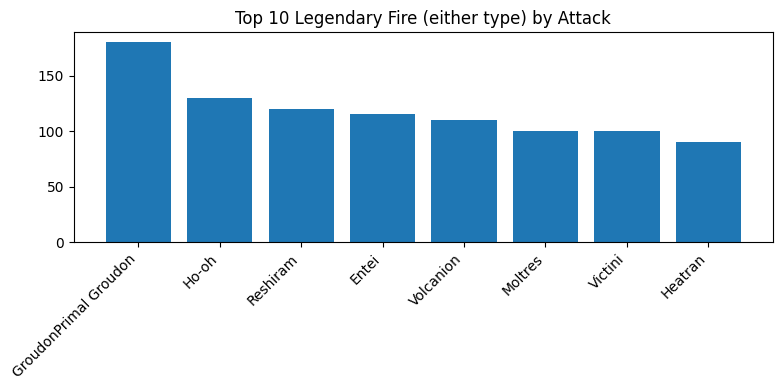

### Active table check

In [5]:
heading("Describe the active table", level=3)
output_box(_safe_json(describe_table()), label="describe_table()", style="info")

heading("Composable pipeline: legendary AND (type_1==Fire OR type_2==Fire)", level=3)

# Step 1: legendary only
legendary = filter_table(
    filters=[{"column": "legendary", "op": "eq", "value": True}],
    logic="and",
    table_id=pokemon_table_id,
    new_table_name="legendary_only",
)
output_box(_safe_json(legendary), label="filter_table(legendary==True)", style="info")

# Step 2: fire in either type
if legendary["ok"]:
    fire = filter_table(
        filters=[
            {"column": "type_1", "op": "eq", "value": "Fire"},
            {"column": "type_2", "op": "eq", "value": "Fire"},
        ],
        logic="or",
        table_id=legendary["data"]["table_id"],
        new_table_name="legendary_fire_either_type",
    )
    output_box(_safe_json(fire), label="filter_table(type_1==Fire OR type_2==Fire)", style="info")

    # Step 3: max attack per Pokémon name (top 10)
    if fire["ok"]:
        agg = groupby_aggregate(
            group_by="name",
            metric="attack",
            agg="max",
            table_id=fire["data"]["table_id"],
            top_n=10,
            new_table_name="top10_legendary_fire_attack",
        )
        output_box(_safe_json(agg), label="groupby_aggregate(name, attack, max)", style="info")

        if agg["ok"]:
            agg_id = agg["data"]["table_id"]
            # Aggregated column name will be attack_max
            plot_res = plot_bar(
                table_id=agg_id,
                x="name",
                y="attack_max",
                title="Top 10 Legendary Fire (either type) by Attack",
            )
            output_box(_safe_json(plot_res), label="plot_bar(...)", style="info")

# Show that the active table did NOT silently change due to plotting
heading("Active table check", level=3)
output_box(_safe_json(list_tables()), label="list_tables()", style="info")


## Part 2: Current Limitations

Let's say we want to compute:

`bulkiness = (hp + defense) / speed`

…then show the **top 6 generations** by mean bulkiness.

We’ll try this with our existing toolset first and see what happens.


In [6]:
heading("Attempt #1 (tool-only): aggregate bulkiness by generation", level=3)

attempt1 = groupby_aggregate(
    group_by="generation",
    metric="bulkiness",  # <-- doesn't exist
    agg="mean",
    table_id=pokemon_table_id,
    top_n=6,
    new_table_name="bulkiness_by_gen",
)
output_box(_safe_json(attempt1), label="groupby_aggregate(metric='bulkiness')", style="info")

output_box(
    "Why this fails:\n"
    "- Our tool DSL can only reference columns that already exist.\n"
    "- We don't have a primitive like add_derived_column(...) yet.",
    label="Observation",
    style="warning",
)

### Attempt #1 (tool-only): aggregate bulkiness by generation

In [7]:
heading("Attempt #2 (tool-only): compute ingredients separately", level=3)

hp_mean = groupby_aggregate(group_by="generation", metric="hp", agg="mean", table_id=pokemon_table_id, top_n=50, new_table_name="hp_mean_by_gen", set_active=False)
def_mean = groupby_aggregate(group_by="generation", metric="defense", agg="mean", table_id=pokemon_table_id, top_n=50, new_table_name="def_mean_by_gen", set_active=False)
spd_mean = groupby_aggregate(group_by="generation", metric="speed", agg="mean", table_id=pokemon_table_id, top_n=50, new_table_name="speed_mean_by_gen", set_active=False)

output_box(_safe_json(hp_mean), label="hp_mean", style="info")
output_box(_safe_json(def_mean), label="def_mean", style="info")
output_box(_safe_json(spd_mean), label="spd_mean", style="info")

output_box(
    "We can compute each ingredient table.\n"
    "But to compute bulkiness_by_gen = (hp_mean + def_mean) / spd_mean, we'd need more primitives:\n"
    "- merge/join tables by generation\n"
    "- arithmetic transforms across columns\n\n"
    "This is the DSL wall: either keep expanding tools into a mini-language,\n"
    "or switch paradigms (code generation).",
    label="Takeaway",
    style="warning",
)


### Attempt #2 (tool-only): compute ingredients separately

### What if the assistant could write Python code dynamically for us to overcome this?

Let's test it out. Let's try to:
- ask the LLM for a Python snippet
- execute it with `exec(...)`

### What if the assistant could write Python code for us to do this?

### Run the generated code (naive exec)

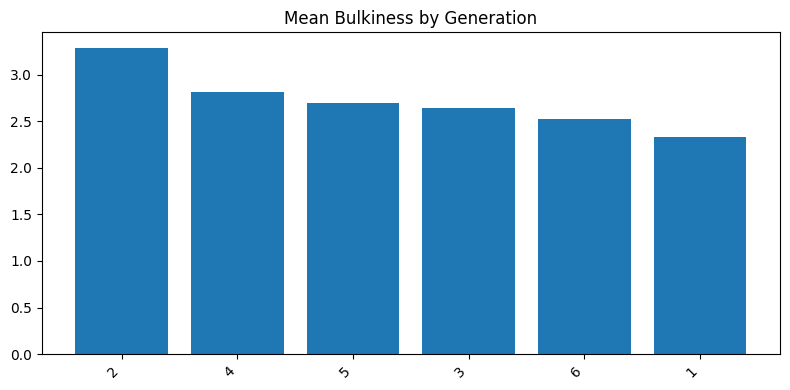

In [8]:
heading("What if the assistant could write Python code for us to do this?", level=3)

output_box(
    "We’re about to do something intentionally naive:\n"
    "- ask the LLM for a Python snippet\n"
    "- run it with exec(...)\n\n"
    "Next, we’ll build guardrails (safe-ish executor + trace).",
    label="What if…",
    style="warning",
)

PROMPT = f"""
Write Python code to answer this EDA task:

Goal:
1) Start from the full Pokémon table in the store
2) Create: bulkiness = (hp + defense) / speed
3) Save the updated table into the store under name 'pokemon_with_bulkiness'
4) Plot the top 6 generations by mean bulkiness
5) Set FINAL_ANSWER (string) with a concise takeaway

Available objects + EXACT APIs:
- store.get(table_id).df -> pandas DataFrame
- store.put(df, name: str, set_active: bool=True) -> table_id (string)
- pokemon_table_id (string)
- groupby_aggregate(...) -> dict  (returns a new table_id in result['data']['table_id'])
- plot_bar(table_id, x, y, title='') -> dict

Rules:
- NO imports
- Always start from:
    df = store.get(pokemon_table_id).df.copy()
- Capture returned table IDs:
    tid = store.put(...)
- After calling plot_bar, print the returned dict as chart_res
- End by setting:
    FINAL_ANSWER = "..."

VERY IMPORTANT:
- groupby_aggregate is NOT pandas. Do NOT pass lists or dicts.
- Use exactly:
    res = groupby_aggregate(group_by="generation", metric="bulkiness", agg="mean", table_id=tid, top_n=6, new_table_name="...", set_active=False)
- The aggregated column name is ALWAYS f"{{metric}}_{{agg}}" (example: bulkiness_mean)
- plot_bar must use y="bulkiness_mean" (not "bulkiness")
- Always print the dict returned by groupby_aggregate and plot_bar.

Return ONLY Python code. No markdown. No backticks.
""".strip()

resp = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "developer", "content": "Return only valid Python code. No markdown."},
        {"role": "user", "content": PROMPT},
    ],
    temperature=0,
)

code_bulkiness = (resp.choices[0].message.content or "").strip()
output_box(code_bulkiness, label="LLM-generated code", style="success")

heading("Run the generated code (naive exec)", level=3)

stdout_buf = io.StringIO()
err = None

g = {
    "pd": pd,
    "np": np,
    "store": store,
    "pokemon_table_id": pokemon_table_id,
    "groupby_aggregate": groupby_aggregate,
    "plot_bar": plot_bar,
}
l: Dict[str, Any] = {}

with contextlib.redirect_stdout(stdout_buf):
    try:
        exec(code_bulkiness, g, l)
    except Exception as e:
        err = f"{type(e).__name__}: {e}"

output_box(stdout_buf.getvalue() or "(no stdout)", label="stdout", style="info")
output_box(err or "(no error)", label="error", style=("error" if err else "success"))

final = l.get("FINAL_ANSWER") or g.get("FINAL_ANSWER")
output_box(final or "(FINAL_ANSWER not set)", label="FINAL_ANSWER", style="info")

# Keep the workshop stable: reset the active table
_ = set_active_table(pokemon_table_id)


### Turning the idea into our agent

In the last section, we did a one-off workflow:

- LLM generates code
- we execute it
- we get a result

Now we’ll make that a **repeatable agent loop** with guardrails and a trace.


In [9]:
heading("Now let’s turn this into a repeatable agent loop", level=3)

output_box(
    "In the last cell, we did this workflow:\n"
    "1) Ask the LLM for a Python snippet\n"
    "2) Run it\n"
    "3) Get analysis + a chart\n\n"
    "Next we’ll build a **coding agent** that can do this repeatedly:\n"
    "- generate a short plan\n"
    "- write code\n"
    "- run it in a controlled environment\n"
    "- learn from errors and retry\n\n"
    "But first, we need a safe-ish way to execute code.",
    label="Bridge",
    style="info",
)


### Now let’s turn this into a repeatable agent loop

## Part 3: Coding agents (Python as the action language)

A coding agent:
- generates a short plan
- writes Python code to perform the analysis
- executes the code
- observes outputs/errors
- retries if needed

If you’ve seen **ReAct**, this is the same loop:
- *Reason/Plan* → *Act* → *Observe* → repeat  
…but here, the *Act* step is **running Python code** (instead of only calling tools).

In this notebook, the agent’s code will interact with the same `AnalyticsStore` using a small set of bridge functions:
- `get_df(table_id=None)`
- `save_df(df, name)`
- `preview(table_id=None, n=10)`


In [10]:
# -----------------------------
# Bridge functions (the CodeAgent API)
# -----------------------------

def get_df(table_id: Optional[str] = None) -> pd.DataFrame:
    """Return a COPY of the DataFrame for safe-ish manipulation."""
    return store.get(table_id).df.copy()

def save_df(df: pd.DataFrame, name: str = "derived", *, set_active: bool = True) -> str:
    """Save a DataFrame back into the store. Returns a new table_id."""
    return store.put(df.copy(), name=name, set_active=set_active)

def preview(table_id: Optional[str] = None, n: int = 10) -> None:
    """Pretty display for students."""
    t = store.get(table_id)
    heading(f"Preview: {t.name} ({t.table_id})", level=4)
    display(t.df.head(max(1, min(int(n), 25))))

heading("Bridge API ready", level=3)
output_box(
    "Available inside generated code:\n"
    "- get_df(table_id=None)\n"
    "- save_df(df, name) -> table_id\n"
    "- preview(table_id=None, n=10)\n"
    "- require_ok(tool_result)\n"
    "- filter_table(...), groupby_aggregate(...), plot_bar(...), scatter_plot(...), histogram(...)\n"
    f"- pokemon_table_id = {pokemon_table_id}",
    label="✅ CodeAgent API",
    style="success",
)


### Bridge API ready

## Part 4: Build a safe executor (and test it)

We just executed model-generated code with `exec(...)`. That’s powerful but risky.

For this workshop, we’ll build a **safe-ish** executor with two goals:
1) Make execution **predictable and teachable** (capture stdout + errors)
2) Reduce obvious risk (no imports, limited builtins, block dangerous syntax)

> Important: This is **not** a production-grade sandbox.  
> In the security section later, we’ll cover stronger isolation options (Docker, nsjail, remote sandboxes, etc.).


In [56]:
# -----------------------------
# Safe executor
# -----------------------------

import traceback

# 1) Safe builtins allowlist (no open/exec/eval/import)
SAFE_BUILTINS = {
    "abs": abs,
    "bool": bool,
    "dict": dict,
    "enumerate": enumerate,
    "float": float,
    "int": int,
    "len": len,
    "list": list,
    "max": max,
    "min": min,
    "print": print,
    "range": range,
    "sorted": sorted,
    "str": str,
    "sum": sum,
    "zip": zip,
}

# 2) AST validation rules (explicit and teachable)
DISALLOWED_NODES = (
    ast.Import, ast.ImportFrom,
    ast.With, ast.AsyncWith,
    ast.Try,
    ast.While,
    ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef,
    ast.Lambda,
    ast.Global, ast.Nonlocal,
)

DISALLOWED_NAMES = {
    # filesystem / process / environment
    "open", "exec", "eval", "compile", "__import__",
    "os", "sys", "subprocess", "pathlib", "shutil",
    # networking
    "socket", "requests", "http", "urllib",
}

def validate_code_ast(code: str) -> Tuple[bool, str]:
    """Return (ok, message)."""
    try:
        tree = ast.parse(code)
    except SyntaxError as e:
        return False, f"SyntaxError: {e}"

    for node in ast.walk(tree):
        if isinstance(node, DISALLOWED_NODES):
            return False, f"Disallowed syntax: {type(node).__name__}"

        # Block suspicious names
        if isinstance(node, ast.Name) and node.id in DISALLOWED_NAMES:
            return False, f"Disallowed name: {node.id}"

        # Block dunder attribute access: obj.__class__, etc.
        if isinstance(node, ast.Attribute) and node.attr.startswith("__"):
            return False, f"Disallowed attribute: {node.attr}"

    return True, "ok"

@dataclass
class CodeRunContext:
    created_table_ids: List[str] = field(default_factory=list)

def make_exec_env(ctx: CodeRunContext) -> Dict[str, Any]:
    """Everything the generated code is allowed to access."""
    def _save_df(df: pd.DataFrame, name: str = "derived") -> str:
        tid = save_df(df, name=name, set_active=False)
        ctx.created_table_ids.append(tid)
        return tid

    env: Dict[str, Any] = {
        "__builtins__": SAFE_BUILTINS,
        # common libs (already imported in the notebook)
        "pd": pd,
        "np": np,
        # your EDA API
        "get_df": get_df,
        "save_df": _save_df,
        "preview": preview,
        "require_ok": require_ok,
        # composable tools
        "filter_table": filter_table,
        "groupby_aggregate": groupby_aggregate,
        "plot_bar": plot_bar,
        "scatter_plot": scatter_plot,
        "histogram": histogram,
        # optional introspection tools
        "describe_table": describe_table,
        "preview_table": preview_table,
        "list_tables": list_tables,
        "set_active_table": set_active_table,
        # useful constants
        "pokemon_table_id": pokemon_table_id,
    }
    return env

def execute_python(code: str, env: Dict[str, Any], ctx: CodeRunContext) -> Dict[str, Any]:
    ok, msg = validate_code_ast(code)
    if not ok:
        return {"ok": False, "stdout": "", "error": msg, "created_table_ids": ctx.created_table_ids, "final_answer": None}

    stdout_buf = io.StringIO()
    err = None
    locals_: Dict[str, Any] = {}

    with contextlib.redirect_stdout(stdout_buf):
        try:
            exec(code, env, locals_)
        except Exception as e:
            err = f"{type(e).__name__}: {e}"
            
        
    final_answer = locals_.get("FINAL_ANSWER")
    return {
        "ok": err is None,
        "stdout": stdout_buf.getvalue(),
        "error": err,
        "created_table_ids": ctx.created_table_ids,
        "final_answer": final_answer,
    }

heading("Safe executor ready", level=3)
output_box(
    "We now have:\n"
    "- SAFE_BUILTINS allowlist\n"
    "- AST validation (blocks imports, while, def/class, dunder attributes, etc.)\n"
    "- execute_python(code, env, ctx) that captures stdout + errors\n\n"
    "Next: let's test what is allowed vs blocked.",
    label="✅ Executor",
    style="success",
)


### Safe executor ready

### Part 4.1: Test the executor (what’s allowed vs blocked)

In [57]:
def run_executor_test(label: str, code: str):
    ctx = CodeRunContext()
    env = make_exec_env(ctx)
    res = execute_python(code, env=env, ctx=ctx)

    heading(label, level=4)
    output_box(code, label="code", style="success")
    output_box(_safe_json(res), label="result", style=("success" if res["ok"] else "error"))
    if res.get("final_answer"):
        output_box(res["final_answer"], label="FINAL_ANSWER", style="info")

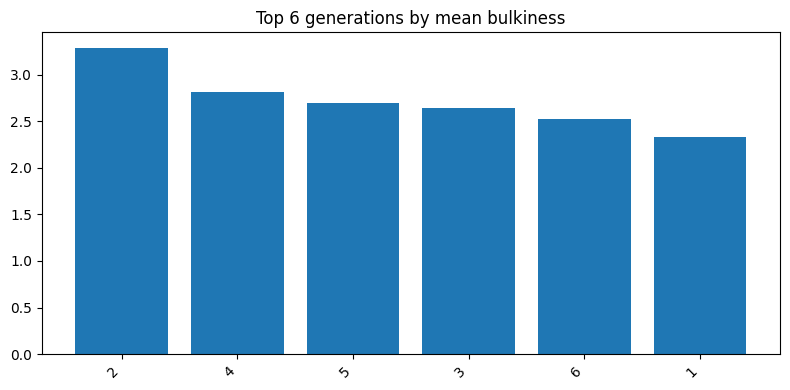

#### ✅ Test 1: Derived metric + aggregate + plot (should work)

In [13]:
# ✅ Test 1: Safe operations (should work, may show a plot)
run_executor_test(
    "✅ Test 1: Derived metric + aggregate + plot (should work)",
    f"""df = get_df(table_id=pokemon_table_id)
df['bulkiness'] = (df['hp'] + df['defense']) / df['speed']
tid = save_df(df, name='pokemon_with_bulkiness')

agg = require_ok(groupby_aggregate(group_by='generation', metric='bulkiness', agg='mean', table_id=tid, top_n=6, new_table_name='bulkiness_by_gen'))
agg_id = agg['data']['table_id']

require_ok(plot_bar(table_id=agg_id, x='generation', y='bulkiness_mean', title='Top 6 generations by mean bulkiness'))

FINAL_ANSWER = f"Created bulkiness and plotted top generations. New table: {{tid}}"
""".strip(),
)

In [14]:
# ❌ Test 2: Import (should be blocked)
run_executor_test(
    "❌ Test 2: import os (should be blocked)",
    """import os
FINAL_ANSWER = "Should not run"
""".strip(),
)

#### ❌ Test 2: import os (should be blocked)

In [15]:
# ❌ Test 3: File access (should be blocked)
run_executor_test(
    "❌ Test 3: open('/etc/passwd') (should be blocked)",
    """data = open('/etc/passwd').read()
FINAL_ANSWER = data[:50]
""".strip(),
)

#### ❌ Test 3: open('/etc/passwd') (should be blocked)

In [16]:
# ❌ Test 4: Dunder attribute access (should be blocked)
run_executor_test(
    "❌ Test 4: dunder attribute access (should be blocked)",
    """x = (1).__class__
FINAL_ANSWER = str(x)
""".strip(),
)

#### ❌ Test 4: dunder attribute access (should be blocked)

In [17]:
# ❌ Test 5: While loop (should be blocked)
run_executor_test(
    "❌ Test 5: while loop (should be blocked)",
    """while True:
    pass
""".strip(),
)

#### ❌ Test 5: while loop (should be blocked)

## Part 5: Build the Coding Agent loop (plan → code → run → retry)

Now we’ll build a coding agent that:

1) reads the question  
2) produces a short **plan** and **Python code**  
3) runs the code in our safe-ish executor  
4) if it fails, feeds the error back to the model and retries  
5) returns a final answer + a trace you can inspect


In [69]:
# -----------------------------
# Structured output schema (Pydantic)
# -----------------------------
from pydantic import BaseModel, Field

class CodeStep(BaseModel):
    plan: str = Field(..., description="A short, human-friendly step-by-step plan (1–3 sentences).")
    code: str = Field(..., description="Python code to execute (no backticks, no markdown).")

SYSTEM_PROMPT_CODE_AGENT = f"""You are a coding agent that helps a data analyst do exploratory data analysis (EDA).

You will be given a question about the current dataset.

You MUST respond as JSON with two fields:
  - plan: 1-3 sentences describing what you will do
  - code: Python code to execute

Sandbox rules for code:
- NO imports
- Do NOT use dunder attributes like __class__ or __dict__
- Do NOT define functions/classes (no def/class/lambda)
- Do NOT use while loops
- Use only the objects listed below

Available objects (EXACT APIs):
- pokemon_table_id : str

- get_df(table_id=None) -> pandas DataFrame (copy)
- save_df(df, name) -> table_id (str)
- preview(table_id=None, n=10) -> displays a preview

- require_ok(result_dict) -> returns the dict, or raises RuntimeError if ok=False
- describe_table(table_id=None) -> dict
- preview_table(table_id=None, n=10) -> dict
- list_tables() -> dict
- set_active_table(table_id) -> dict

Composable tools:
- filter_table(filters, logic='and'|'or', table_id=None, new_table_name='filtered') -> dict (with data.table_id)
- groupby_aggregate(group_by, metric, agg='mean', table_id=None, top_n=10, new_table_name='grouped') -> dict (with data.table_id)
  - The aggregated column is named f"{{metric}}_{{agg}}" (e.g., bulkiness_mean)
- plot_bar(table_id, x, y, title='') -> dict
- scatter_plot(x, y, table_id=None, title='') -> dict
- histogram(column, table_id=None, bins=20, title='') -> dict

How to make tool failures obvious:
- Wrap tool calls with require_ok(...). That way errors raise exceptions and you can retry.

Important plotting rule (to avoid silent failures):
- plot_bar plots from a TABLE. It does NOT accept pandas Series/arrays.
  Use:
    agg = require_ok(groupby_aggregate(...))
    agg_id = agg['data']['table_id']
    require_ok(plot_bar(table_id=agg_id, x='generation', y='bulkiness_mean', title='...'))

Output convention:
- End your code by setting:
    FINAL_ANSWER = "a concise takeaway"

Prefer starting from:
  df = get_df(table_id=pokemon_table_id)
unless the question explicitly asks to use a different table_id.

CRITICAL INVARIANTS (read carefully):
- get_df(...) returns a COPY. If you create new columns (like bulkiness), tools will NOT see them until you save_df(...)
- save_df(df, name) returns a STRING table_id like "tbl_1234abcd". Always assign it: tid = save_df(...)
- Always pass table_id explicitly into tool calls (groupby_aggregate, plot_bar). Do NOT pass table names.

Tool contracts (NOT pandas):
- groupby_aggregate(group_by="generation", metric="bulkiness", agg="mean", table_id=tid, top_n=6, new_table_name="...") -> dict
- The aggregated column name is ALWAYS f"{{metric}}_{{agg}}" (example: bulkiness_mean)
- plot_bar(table_id=agg_res["data"]["table_id"], x="generation", y="bulkiness_mean", title="...") -> dict

Use require_ok ONLY on dict-returning tool calls (groupby_aggregate, plot_bar, filter_table, etc.).
Do NOT wrap save_df(...) with require_ok because save_df returns a string table_id.
""".strip()

# -----------------------------
# Parsing helper (SDK parse → fallback JSON mode)
# -----------------------------
def _parse_structured(model: str, messages: List[Dict[str, Any]], response_model: type[BaseModel]) -> Tuple[Optional[BaseModel], str]:
    if client is None:
        return None, "OpenAI client not available"

    # Preferred: SDK parse
    try:
        resp = client.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=response_model,
            temperature=0,
        )
        msg = resp.choices[0].message
        parsed = getattr(msg, "parsed", None)
        return parsed, (msg.content or "")
    except Exception:
        pass

    # Fallback: JSON mode
    resp = client.chat.completions.create(
        model=model,
        messages=messages,
        response_format={"type": "json_object"},
        temperature=0,
    )
    txt = resp.choices[0].message.content or "{}"
    try:
        data = json.loads(txt)
        return response_model.model_validate(data), txt
    except Exception:
        return None, txt

def render_code_trace(trace: List[Dict[str, Any]]) -> None:
    if not trace:
        output_box("No trace.", label="Trace", style="warning")
        return

    for i, step in enumerate(trace, start=1):
        heading(f"Attempt {i}", level=4)
        output_box(step.get("plan",""), label="Plan", style="info")
        output_box(step.get("code",""), label="Generated code", style="success")
        if step.get("stdout"):
            output_box(step["stdout"], label="stdout", style="info")
        if step.get("error"):
            output_box(step["error"], label="error", style="error")
        if step.get("created_table_ids"):
            output_box(", ".join(step["created_table_ids"]), label="tables created", style="success")
        if step.get("final_answer"):
            output_box(step["final_answer"], label="FINAL_ANSWER", style="success")

def run_code_agent(question: str, model: str = MODEL, max_attempts: int = 3) -> Dict[str, Any]:
    """Run the coding agent and return {final, trace}."""
    messages: List[Dict[str, Any]] = [
        {"role": "developer", "content": SYSTEM_PROMPT_CODE_AGENT},
        {"role": "user", "content": question},
    ]

    trace: List[Dict[str, Any]] = []

    for _ in range(max_attempts):
        parsed, raw = _parse_structured(model=model, messages=messages, response_model=CodeStep)
        if parsed is None:
            return {"final": "Could not parse a structured CodeStep from the model output.", "trace": trace}

        ctx = CodeRunContext()
        env = make_exec_env(ctx)
        result = execute_python(parsed.code, env=env, ctx=ctx)

        step = {
            "plan": parsed.plan,
            "code": parsed.code,
            "stdout": result.get("stdout", ""),
            "error": result.get("error"),
            "created_table_ids": result.get("created_table_ids", []),
            "final_answer": result.get("final_answer"),
        }
        trace.append(step)

        if result["ok"] and result.get("final_answer"):
            return {"final": result["final_answer"], "trace": trace}

        feedback = f"""Your code did not complete successfully."
            
### Error: 
{result.get('error')}

### Stdout:
{result.get('stdout')}

### Here was your code:
{parsed.code}

Reminders:
- No imports, no def/class/lambda, no while, no dunder attributes
- Use require_ok(...) around tool calls
- plot_bar(table_id=..., x='col', y='col') (no Series/arrays)
- End by setting FINAL_ANSWER = '...'


Task:
Please analyze the error and the code that the error is happening with, try to find the root cause.
You may add debug logs to help you examine types, results of commands, etc. if that will help you fix the code.
"""

        print(feedback)
        messages.append({"role": "assistant", "content": json.dumps({"plan": parsed.plan, "code": parsed.code})})
        messages.append({"role": "user", "content": feedback})

    return {"final": "Reached max_attempts without a successful run.", "trace": trace}

heading("Coding agent ready", level=3)
output_box(
    "Use: res = run_code_agent(question)\nThen inspect res['trace'] with render_code_trace(res['trace']).",
    label="✅ CodeAgent",
    style="success",
)


### Coding agent ready

### Try the coding agent

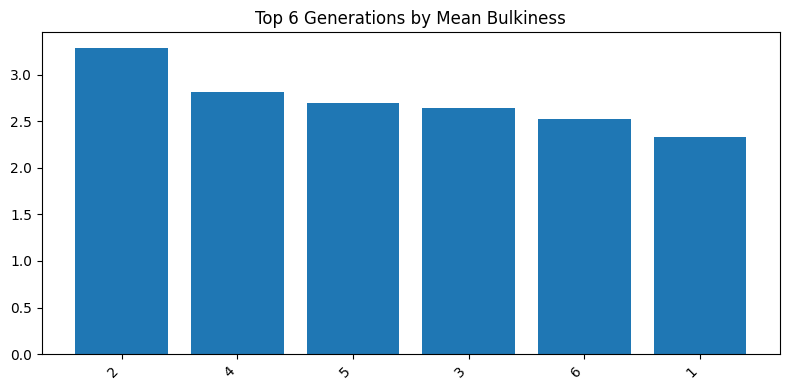

#### Attempt 1

In [41]:
_ = set_active_table(pokemon_table_id)

question = """Create a derived metric bulkiness = (hp + defense) / speed for all Pokémon.
Then show the top 6 generations by mean bulkiness as a bar chart.
Finish with a concise takeaway.
""".strip()

res = run_code_agent(question, max_attempts=3)
llm_response(res["final"], label="Final answer")
render_code_trace(res["trace"])


## Part 6: Demos — things that become easier with a coding agent

These examples are intentionally chosen to go beyond the Workshop 4 DSL without adding new tools.

As you run them, inspect the trace:
- what code did the agent write?
- what tables did it create?
- what plots did it generate?


### Demo 1: Top 3 Pokémon per generation by special attack

In [42]:
question = """For each generation, find the top 3 Pokémon by sp_atk.
Save the result as a new table named 'top3_sp_atk_per_generation' and show a preview of the first 12 rows.
Finish with printing the top 12 rows.
""".strip()

res = run_code_agent(question, max_attempts=3)
llm_response(res["final"], label="Final answer")
render_code_trace(res["trace"])


#### Attempt 1

#### Attempt 2

### Demo 2: A derived “balance score” using z-scores

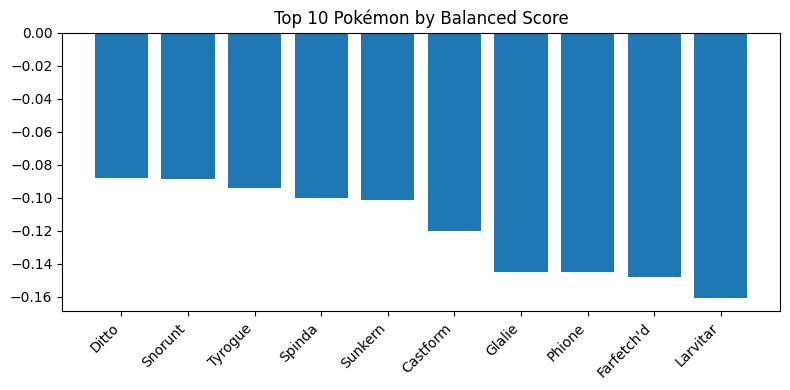

#### Attempt 1

In [43]:
question = """Create z-scores for these numeric stats: hp, attack, defense, sp_atk, sp_def, speed.
Define balanced_score = -std_dev(z_scores) across those stats (so more balanced Pokémon score higher).
Show the top 10 Pokémon by balanced_score as a bar chart.
Finish with a concise takeaway.
""".strip()

res = run_code_agent(question, max_attempts=3)
llm_response(res["final"], label="Final answer")
render_code_trace(res["trace"])


### Demo 3: Correlations (find a strong relationship and visualize it)

Your code did not complete successfully."

### Error: 
AttributeError: 'numpy.float64' object has no attribute 'index'

### Stdout:


### Here was your code:
df = get_df(table_id=pokemon_table_id)
correlation_matrix = df[['hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total']].corr()
strongest_positive = correlation_matrix.unstack().sort_values(ascending=False).drop_duplicates().iloc[1]
strongest_pair = strongest_positive.index
x, y = strongest_pair
require_ok(scatter_plot(x=x, y=y, table_id=pokemon_table_id, title=f'Scatter plot of {x} vs {y}'))
FINAL_ANSWER = f'The strongest positive correlation is between {x} and {y} with a value of {strongest_positive:.2f}.'

Reminders:
- No imports, no def/class/lambda, no while, no dunder attributes
- Use require_ok(...) around tool calls
- plot_bar(table_id=..., x='col', y='col') (no Series/arrays)
- End by setting FINAL_ANSWER = '...'


Task:
Please analyze the error and the code that the error is happening with, try to find the root 

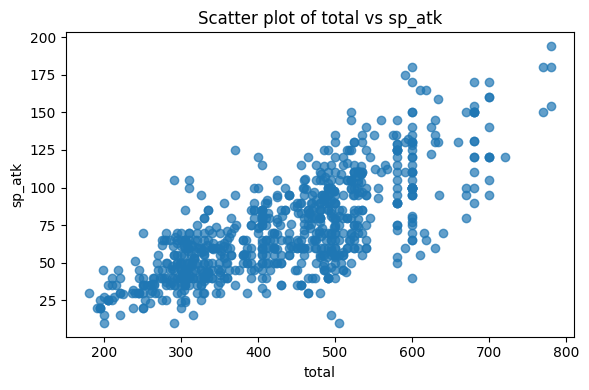

#### Attempt 1

#### Attempt 2

#### Attempt 3

In [70]:
question = """Compute the correlation matrix among numeric columns: hp, attack, defense, sp_atk, sp_def, speed, total.
Find the strongest positive correlation (excluding self-correlation).
Then show a scatter plot of that pair (using scatter_plot).
Finish with a concise takeaway that includes the pair and correlation value.
"""

res = run_code_agent(question, max_attempts=3)
llm_response(res["final"], label="Final answer")
render_code_trace(res["trace"])


## Part 7: Security notes (and stronger sandbox options)

So far we’ve run LLM-generated code **locally**. Even with our “safeish” executor, you should treat this as **educational**, not production security.

### What can go wrong?
- **Data exfiltration** (reading local files, env vars, API keys)
- **Resource abuse** (infinite loops, huge allocations, disk fill)
- **Network calls** (sending data out)
- **Sandbox escapes** (using allowed libraries in unexpected ways)

### Defense-in-depth (stronger → safer)

**1) Least privilege in your executor**
- Expose *only* the functions you actually want the agent to use
- Avoid putting secrets (API keys, tokens) in the execution environment
- Make failures loud (raise on `ok=False`) so you can retry safely

**2) Language-level restrictions (helpful, not sufficient)**
- `RestrictedPython` restricts language features, but it explicitly warns it is **not** a full sandbox.  
  https://pypi.org/project/RestrictedPython/

**3) Interpreters that execute AST step-by-step**
- Hugging Face `smolagents` implements a `LocalPythonExecutor` that executes code operation-by-operation and blocks unapproved imports, dunder access, etc.  
  It also enforces limits (e.g., loop iteration caps).  
  https://huggingface.co/docs/smolagents/en/tutorials/secure_code_execution

**4) OS-level isolation (recommended for real applications)**
- Run code in an isolated process/container with:
  - restricted filesystem (read-only, temp dirs only)
  - no network (or tightly controlled egress)
  - CPU/memory/time limits
- Tools like **nsjail** provide Linux namespace + seccomp + cgroup-based isolation:  
  https://github.com/google/nsjail

**5) Remote sandboxes / “code interpreter” services**
- Services like **E2B** provide isolated sandboxes specifically for running AI-generated code:  
  https://e2b.dev/  
- `smolagents` also documents running code in remote sandboxes (E2B, Docker, Modal, etc.):  
  https://huggingface.co/docs/smolagents/en/tutorials/secure_code_execution

### Two common architecture choices
1) **Sandbox only the code snippets** (agent stays local; code runs remotely)  
2) **Sandbox the entire agent system** (stronger isolation, but requires more setup + credential handling)

For most production use cases, you should prefer **OS-level isolation or remote sandboxes** over local `exec`.


## Part 8: Exercises

Try these prompts with `run_code_agent(...)`.  
(If you don’t have an API key, you can still practice by writing the pandas code yourself and running it through `execute_python(...)`.)

### Exercise 1 — Fire in either type
Filter to legendary Pokémon where **type_1 == Fire OR type_2 == Fire**, then show the top 10 by attack.

### Exercise 2 — “Glass cannon” score
Define `glass_cannon = sp_atk - defense`.  
Show the top 10 Pokémon by glass_cannon (and plot them).

### Exercise 3 — Compare legendary vs non-legendary
Compare the distribution of `speed` for legendary vs non-legendary Pokémon (histograms) and give a takeaway.

### Exercise 4 — New dataset (bonus)
Swap in a different CSV and see if your agent still works.  
(What breaks first: prompt assumptions, tool contracts, or code execution?)

---

Tip: When a question is ambiguous, have the agent call `describe_table()` or `preview()` first.


## Wrap-up

You now have two complementary layers for natural-language EDA:

- A small, composable **tool DSL** (Workshop 4)  
- A **coding agent** that can go beyond the DSL when needed (Workshop 5)

Key takeaways:
- Use a DSL for reliability and safety (especially in high-stakes settings)
- Use code generation for flexibility — but invest in sandboxing, observability, and least-privilege design
